# IMPORTING MODULES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# READING & CALLING THE CSV FILE

In [3]:
df1 = pd.read_csv("data_date.csv")

In [4]:
df1

,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63
...,...,...,...,...
17260,2025-01-16,United Kingdom of Great Britain and Northern I...,Unhealthy for Sensitive Groups,102
17261,2025-01-16,United States of America,Moderate,93
17262,2025-01-16,Uzbekistan,Unhealthy,170
17263,2025-01-16,Vatican,Good,25


# PROGRAMS

In [5]:
# Check wheather the Dataset is containing NaN values or not
df1.isna()

,Date,Country,Status,AQI Value
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
17260,False,False,False,False
17261,False,False,False,False
17262,False,False,False,False
17263,False,False,False,False


In [6]:
# To sum all the NaN values
df1.isna().sum()

Date         0
Country      0
Status       0
AQI Value    0
dtype: int64

In [7]:
# To get the basic information of the Dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17265 entries, 0 to 17264
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       17265 non-null  object
 1   Country    17265 non-null  object
 2   Status     17265 non-null  object
 3   AQI Value  17265 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 539.7+ KB


In [8]:
# To get the discription of the Dataset
df1.describe()

,AQI Value
count,17265.000000
mean,62.865566
std,49.617850
min,1.000000
25%,29.000000
50%,53.000000
75%,83.000000
max,963.000000


In [9]:
# To know the top 5 countries
df1.head()

,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63


In [10]:
# To know the bottom 5 countries
df1.tail()

,Date,Country,Status,AQI Value
17260,2025-01-16,United Kingdom of Great Britain and Northern I...,Unhealthy for Sensitive Groups,102
17261,2025-01-16,United States of America,Moderate,93
17262,2025-01-16,Uzbekistan,Unhealthy,170
17263,2025-01-16,Vatican,Good,25
17264,2025-01-16,Vietnam,Unhealthy for Sensitive Groups,131


In [11]:
# Create pivot table
pivot_table = pd.pivot_table(df1, values=['AQI Value'], index= 'Country', aggfunc= 'mean')
pivot_table = pivot_table.reset_index()
pivot_table

,Country,AQI Value
0,Albania,26.661417
1,Algeria,59.837398
2,Andorra,29.204724
3,Angola,109.462366
4,Argentina,35.968504
...,...,...
137,Uzbekistan,72.112903
138,Vatican,46.440945
139,Venezuela,15.694215
140,Vietnam,85.992126


In [12]:
# Split the Date column into Year, Month and Day
df1 = pd.DataFrame(df1)
df1['Date'] = df1['Date'].astype(str)
df1[['Year', 'Month', 'Day']] = df1['Date'].str.split('-', expand=True)

df1['Day'] = df1['Day'].astype(int)
df1['Month'] = df1['Month'].astype(int)
df1['Year'] = df1['Year'].astype(int)

df1.drop(['Date'], axis=1)
print(df1)

             Date                                            Country  \
0      2022-07-21                                            Albania   
1      2022-07-21                                            Algeria   
2      2022-07-21                                            Andorra   
3      2022-07-21                                             Angola   
4      2022-07-21                                          Argentina   
...           ...                                                ...   
17260  2025-01-16  United Kingdom of Great Britain and Northern I...   
17261  2025-01-16                           United States of America   
17262  2025-01-16                                         Uzbekistan   
17263  2025-01-16                                            Vatican   
17264  2025-01-16                                            Vietnam   

                               Status  AQI Value  Year  Month  Day  
0                                Good         14  2022      7   21

In [13]:
df1

,Date,Country,Status,AQI Value,Year,Month,Day
0,2022-07-21,Albania,Good,14,2022,7,21
1,2022-07-21,Algeria,Moderate,65,2022,7,21
2,2022-07-21,Andorra,Moderate,55,2022,7,21
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113,2022,7,21
4,2022-07-21,Argentina,Moderate,63,2022,7,21
...,...,...,...,...,...,...,...
17260,2025-01-16,United Kingdom of Great Britain and Northern I...,Unhealthy for Sensitive Groups,102,2025,1,16
17261,2025-01-16,United States of America,Moderate,93,2025,1,16
17262,2025-01-16,Uzbekistan,Unhealthy,170,2025,1,16
17263,2025-01-16,Vatican,Good,25,2025,1,16


In [14]:
# Create a new pivot table
pivot_table = pd.pivot_table(df1, values=['AQI Value', 'Year', 'Month', 'Day'], index= 'Country', aggfunc= 'mean')
pivot_table = pivot_table.reset_index()
pivot_table

,Country,AQI Value,Day,Month,Year
0,Albania,26.661417,16.023622,7.685039,2022.732283
1,Algeria,59.837398,15.902439,7.642276,2022.699187
2,Andorra,29.204724,16.023622,7.685039,2022.732283
3,Angola,109.462366,16.387097,7.494624,2022.236559
4,Argentina,35.968504,16.023622,7.685039,2022.732283
...,...,...,...,...,...
137,Uzbekistan,72.112903,16.000000,7.653226,2022.750000
138,Vatican,46.440945,16.023622,7.685039,2022.732283
139,Venezuela,15.694215,16.256198,7.727273,2022.702479
140,Vietnam,85.992126,16.023622,7.685039,2022.732283


In [15]:
# To remove the decimal points of Day, Month & Year 
df = pd.DataFrame(pivot_table)
df['Day'] = df['Day'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Year'] = df['Year'].astype(int)
df['AQI Value'] = df['AQI Value'].astype(int)
print(df)

        Country  AQI Value  Day  Month  Year
0       Albania         26   16      7  2022
1       Algeria         59   15      7  2022
2       Andorra         29   16      7  2022
3        Angola        109   16      7  2022
4     Argentina         35   16      7  2022
..          ...        ...  ...    ...   ...
137  Uzbekistan         72   16      7  2022
138     Vatican         46   16      7  2022
139   Venezuela         15   16      7  2022
140     Vietnam         85   16      7  2022
141      Zambia        117   16      7  2022

[142 rows x 5 columns]


In [16]:
pivot_table = pd.pivot_table(df, values=['AQI Value', 'Year', 'Month', 'Day'], index= 'Country', aggfunc= 'mean')
pivot_table = pivot_table.reset_index()
pivot_table

,Country,AQI Value,Day,Month,Year
0,Albania,26.0,16.0,7.0,2022.0
1,Algeria,59.0,15.0,7.0,2022.0
2,Andorra,29.0,16.0,7.0,2022.0
3,Angola,109.0,16.0,7.0,2022.0
4,Argentina,35.0,16.0,7.0,2022.0
...,...,...,...,...,...
137,Uzbekistan,72.0,16.0,7.0,2022.0
138,Vatican,46.0,16.0,7.0,2022.0
139,Venezuela,15.0,16.0,7.0,2022.0
140,Vietnam,85.0,16.0,7.0,2022.0


C:\Users\Diya Surana\AppData\Local\Temp\ipykernel_9276\2522857103.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


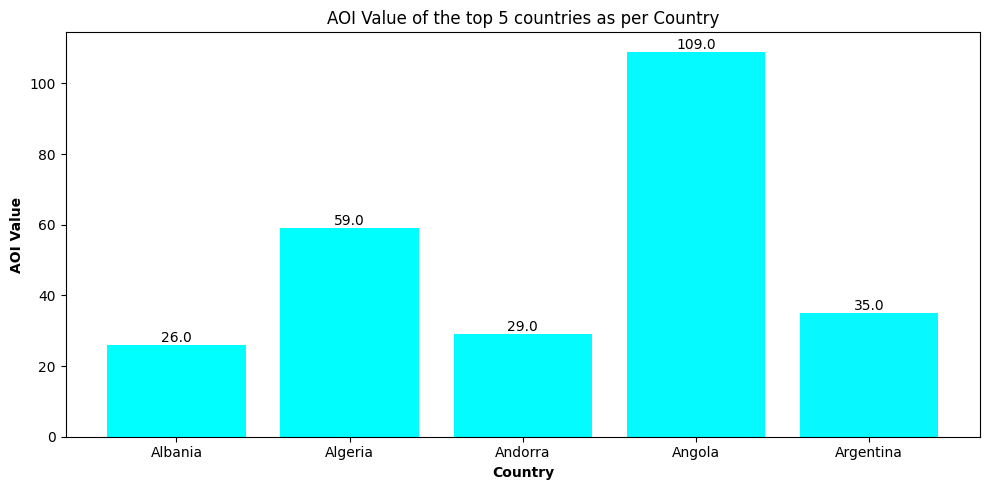

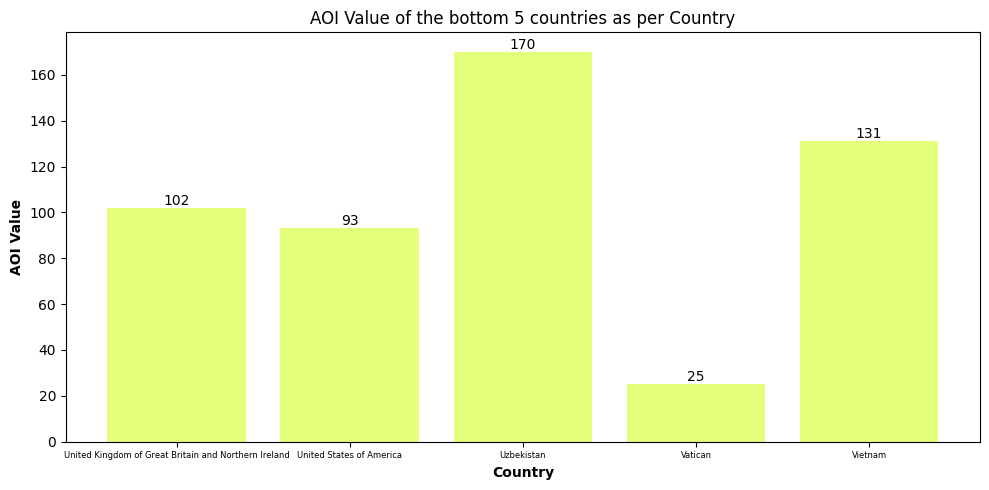

In [17]:
# To see the AOI VAlue of the top 5 countries 
plt.figure(figsize=(10, 5))
bars = plt.bar(pivot_table['Country'].head(), pivot_table['AQI Value'].head(), color= plt.cm.cool(np.linspace(0, 1, len(pivot_table))))
plt.xlabel("Country", fontweight = 'bold')
plt.ylabel("AOI Value", fontweight = 'bold')
plt.title("AOI Value of the top 5 countries as per Country")
plt.tight_layout()

#Adding Data Labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# To see the AOI VAlue of the bottom 5 countries 

plt.figure(figsize=(10, 5))
bars = plt.bar(df1['Country'].tail(), df1['AQI Value'].tail(), color= plt.cm.Wistia(np.linspace(0, 1, len(df1))))
plt.xlabel("Country", fontweight = 'bold') 
plt.ylabel("AOI Value", fontweight = 'bold') 
plt.title("AOI Value of the bottom 5 countries as per Country")
plt.xticks(fontsize=6)
#Adding Data Labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), ha='center', va='bottom')
plt.tight_layout()
plt.show()

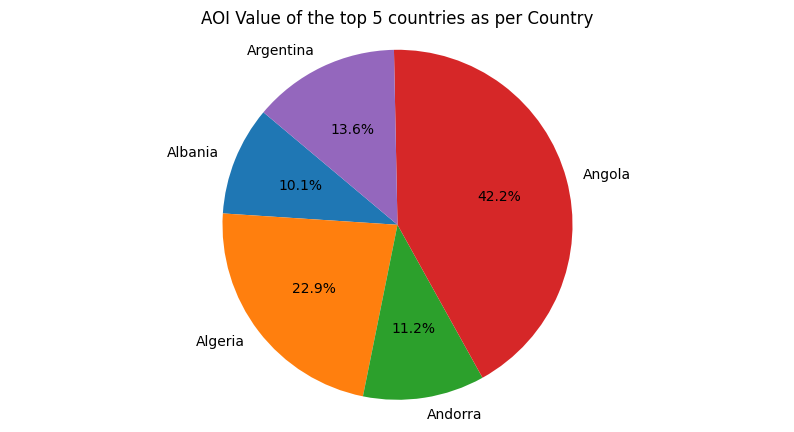

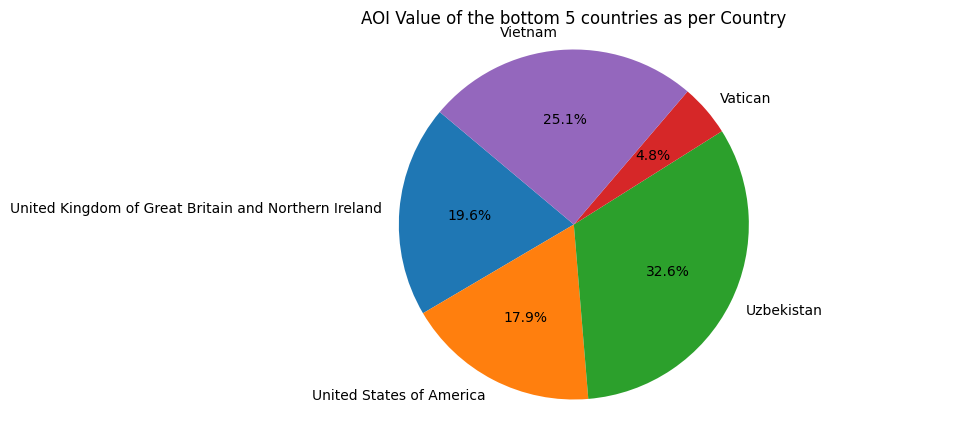

In [18]:
# Create a pie chart of the top 5 countries
plt.figure(figsize=(10, 5))
plt.pie(pivot_table['AQI Value'].head(), labels=pivot_table['Country'].head(), autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title("AOI Value of the top 5 countries as per Country")
plt.show()

# Create a pie chart of the bottom 5 countries
plt.figure(figsize=(10, 5))
plt.pie(df1['AQI Value'].tail(), labels=df1['Country'].tail(), autopct='%1.1f%%', startangle=140,)
plt.axis('equal')
plt.title("AOI Value of the bottom 5 countries as per Country")
plt.show()

In [ ]:
# If the user want to know about the random country
def get_AQI_value(country_name):
    country_data = df1[df1['Country'] == country_name]
    if not country_data.empty:
        return country_data['AQI Value'].values[0]
    else: return f"AQI Value for {country_name} not found."
country_name = input("Enter the name of the Country to know its AQI Value: ")
AQI_value = get_AQI_value(country_name)
print(f"The AQI Value of {country_name} is: {AQI_value}")

In [ ]:
fig = px.choropleth(df1, locations= 'Country',
                    locationmode='country names',
                    color="AQI Value",
                    hover_name="Country",
                    title="Country as per thier AQI Value",
                    color_continuous_scale="tealgrn",)
fig.show()

In [ ]:
df = pd.DataFrame(df1)
print(df)

             Date                                            Country  \
0      2022-07-21                                            Albania   
1      2022-07-21                                            Algeria   
2      2022-07-21                                            Andorra   
3      2022-07-21                                             Angola   
4      2022-07-21                                          Argentina   
...           ...                                                ...   
17260  2025-01-16  United Kingdom of Great Britain and Northern I...   
17261  2025-01-16                           United States of America   
17262  2025-01-16                                         Uzbekistan   
17263  2025-01-16                                            Vatican   
17264  2025-01-16                                            Vietnam   

                               Status  AQI Value  Year  Month  Day  
0                                Good         14  2022      7   21

In [ ]:
# To know the AQI Value of countries as per Year
print("You can only know the AQI value for the following years because the Dataset contains only the following years:\n1. 2022\n2. 2023\n3. 2024\n4. 2025")
input_country = input("Enter the country name: ")
input_year = int(input("Enter the year: "))

filtered_data = df[(df['Country'] == input_country) & (df['Year'] == input_year)]

if not filtered_data.empty:
    print(f"The AQI Value for {input_country} in {input_year} is {filtered_data['AQI Value'].values[0]}")
else:
    print(f"No data available for {input_country} in {input_year}.")

You can only know the AQI value for the following years because the Dataset contains only the following years:
1. 2022
2. 2023
3. 2024
4. 2025
The AQI Value for India in 2022 is 162
